## Supervised Learning
#### by **Ivan Alducin**
<p><img src="https://preview.redd.it/rfgtsej8fhv71.jpg?auto=webp&s=99a5d000ff2baaac79a8d15c7135c3677f105159" width="1000"></p>

## Exploratory Data Analysis
<p>Vamos a trabajar con el conjunto de datos de <code>Heart Attack</code>, el objetivo es predecir bajo que escenario es más probable que un paciente pueda tener un ataque al corazón  Un experto en medicina cardiovasuclar puede predecir esto sin hacer uso de <i>Machine Learning</i>, pero probablemente no instantáneamente, ¡y ciertamente no si estamos tratando con cientos o miles de muestras!.
    
A continuación una breve explicación de las variables del dataset:
    
- <b>age:</b> Age of the patient
- <b>sex:</b> Sex of the patient
- <b>cp:</b> Chest pain type ~ 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic
- <b>trtbps:</b> Resting blood pressure (in mm Hg)
- <b>chol:</b> Cholestoral in mg/dl fetched via BMI sensor
- <b>fbs:</b> (fasting blood sugar > 120 mg/dl) ~ 1 = True, 0 = False
- <b>restecg:</b> Resting electrocardiographic results ~ 0 = Normal, 1 = ST-T wave normality, 2 = Left ventricular hypertrophy
- <b>thalachh:</b> Maximum heart rate achieved
- <b>oldpeak:</b> Previous peak
- <b>slp:</b> Slope
- <b>caa:</b> Number of major vessels
- <b>thall:</b> Thalium Stress Test result ~ (0,3)
- <b>exng:</b> Exercise induced angina ~ 1 = Yes, 0 = No
- <b>output:</b>  Target variable</p>

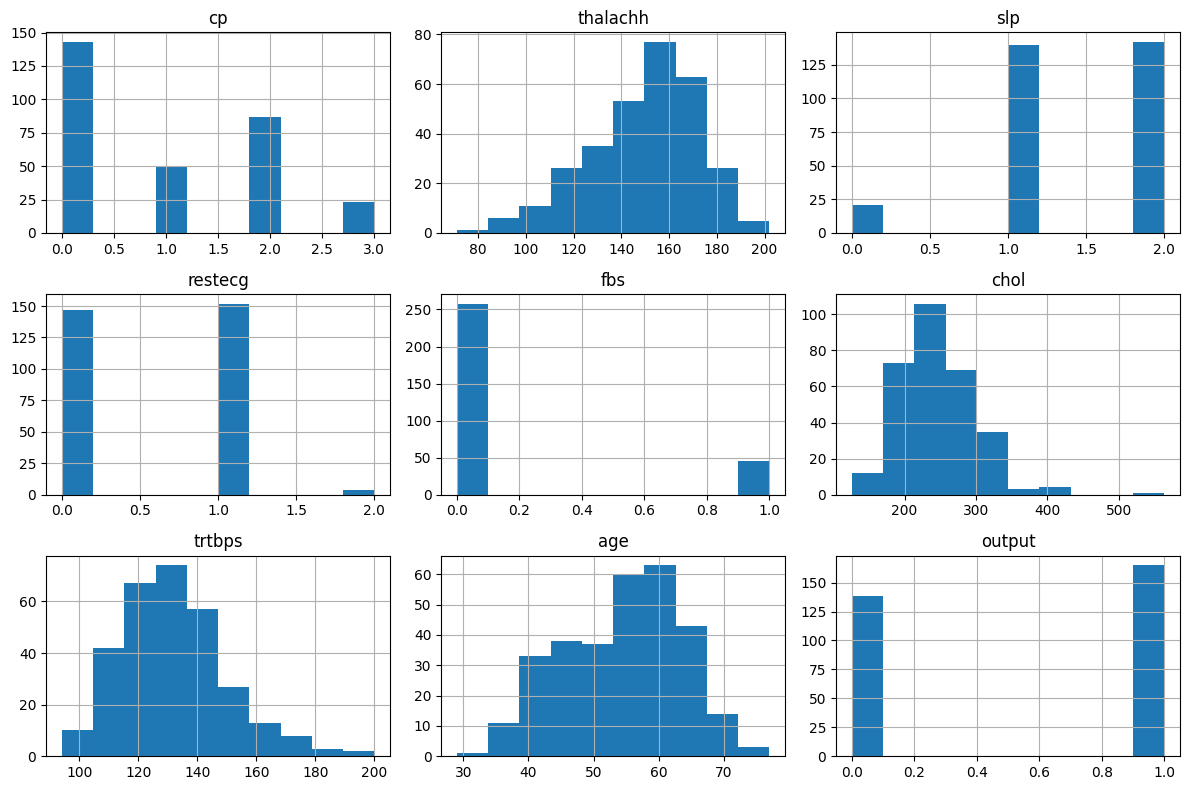

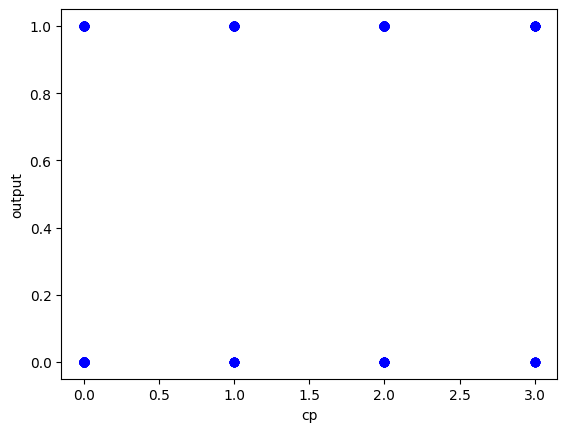

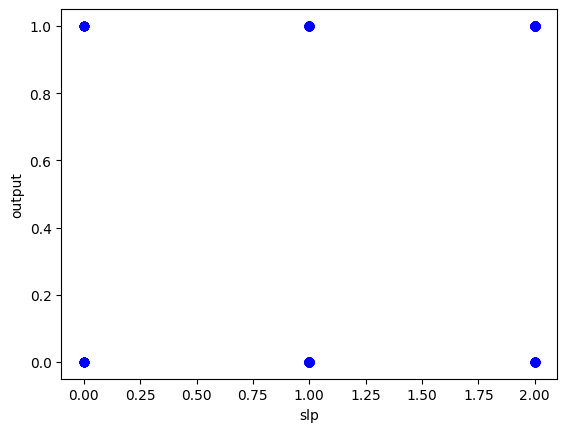

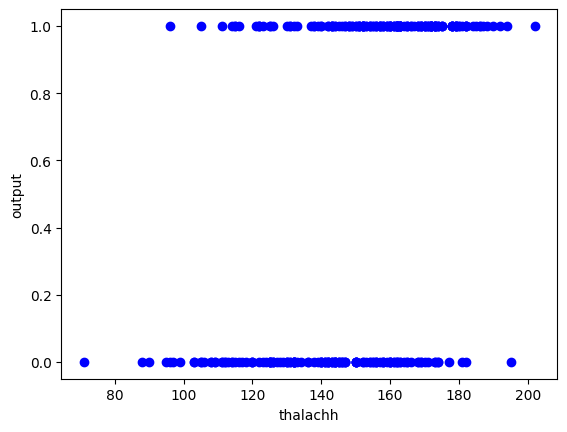

In [3]:
# Archivo Heart Attack.csv - ¿Cuales son los factores que pueden incrementar o disminuir la probabilidad de un ataque al corazón?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Heart Attack.csv")

df

# Exploración de datos
df.describe()

# Correlación de las variables independientes con la dependiente
df.corr()['output'].sort_values(ascending=False)


cdf = df[['cp', 'thalachh', 'slp', 'restecg', 'fbs', 'chol', 'trtbps', 'age', 'output']]
cdf.head(9)

# Visualización en histograma

viz = cdf[['cp', 'thalachh', 'slp', 'restecg', 'fbs', 'chol', 'trtbps', 'age', 'output']]

viz.hist(figsize=(12,8))

plt.tight_layout()
plt.show()

plt.scatter(cdf.cp, cdf.output, color='blue')
plt.xlabel('cp')
plt.ylabel('output')
plt.show()

plt.scatter(cdf.slp, cdf.output, color='blue')
plt.xlabel('slp')
plt.ylabel('output')
plt.show()


plt.scatter(cdf.thalachh, cdf.output, color='blue')
plt.xlabel('thalachh')
plt.ylabel('output')
plt.show()

In [4]:
# Hacer EDA (Exploratory Data Analysis) suele ser un tanto laborioso dependiendo del detalle al que se quiera llevar, pero prueba la siguiente librería, puede que a partir de ahora, tu EDA sea más fácil ;)
from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 102.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
y = cdf['output'].values
X = cdf.drop(['output'], axis=1)

In [6]:
# Bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1, stratify=y)

In [7]:
# Escalamiento con train

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## k-Nearest Neighbors
<p>Habiendo hecho un Análisis Exploratorio de los factores que pueden o no tener más posibilidad de un ataque al corazón, es hora de crear tu primer clasificador!!! usando el algoritmo de k-NN.
    
<b>Nota</b>: es importante garantizar que los datos esten en el formato requerido por la librería de <code>scikit-learn</code>. La información debe estar en una matriz en la que cada columna sea una variable y cada fila una observación diferente, en este caso, el registro de análisis clinico por paciente. Y la variable objetivo debe ser una sola columna con el mismo número de observaciones.</p>

In [9]:
# Importa la librería para un clasificador k-NN de sklearn
from sklearn.neighbors import KNeighborsClassifier

# Crea dos arreglos "X", "y" que contengan los valores de las variables independientes y la variable objetivo
y = cdf['output'].values
X = cdf.drop(['output'], axis=1)

# Crea un clasificador k-NN con 6 vecinos
knn = KNeighborsClassifier(n_neighbors=6)

# Ajusta el clasificador a las variables
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Predicción
<p>Una vez que entrenamos al clasificador k-NN, ahora lo podemos usar para predecir un nuevo registro. Para este caso,  no hay datos sin clasificar disponibles ya que todos se usaron para entrenar al modelo. Para poder calcular una predicción, vamos a usar el método <code>.predict()</code> pero, para esto vamos a simular una observación completamente nueva</p>

In [11]:
# Crea un arreglo simulando una observación
X_new = np.array([[0.5, 0.6, 0.3, 0.8, 0.2, 0.4, 0.7, 0.1]])

# Predice la clasificación para el arreglo que creaste
y_new_pred = knn.predict(X_new)
print("Prediction: {}".format(y_new_pred))

Prediction: [1]


## Reconocimiento de digitos
<p>Hasta ahora, solo hemos realizado una clasificación binaria, ya que la variable objetivo tenía dos resultados posibles. En los siguientes ejercicios, trabajarás con el conjunto de datos de reconocimiento de dígitos MNIST, que tiene 10 clases, ¡los dígitos del 0 al 9! Una versión reducida del conjunto de datos <a href="http://yann.lecun.com/exdb/mnist/">MNIST</a> es uno de los conjuntos de datos incluidos en <code>scikit-learn</code>

Cada muestra de este conjunto de datos es una imagen de 28x28 que representa un dígito escrito a mano. Cada píxel está representado por un número entero en el rango de 1 a 784, lo que indica niveles variables de negro.

<p><img src="https://miro.medium.com/max/1400/1*hVdoiW35FXUE-fZ0HI30Tw.jpeg" width="350"></p>

In [13]:
# Importa el archivo de MNIST
from sklearn.datasets import fetch_openml
df_mnist = pd.read_csv("MNIST.csv")

In [14]:
# Crea una variable 'cols' para hacer referencia a todas las columnas que contienen la palabra 'pixel'
cols = [col for col in df_mnist.columns if 'pixel' in col]

El número es: 0


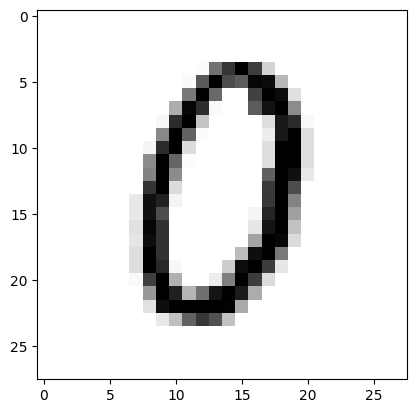

In [15]:
# Vamos a imprimir un digito
i = 5
print("El número es:", df_mnist.loc[i, 'label'])
plt.imshow(df_mnist.loc[i, cols].values.reshape((28,28)).astype(float), cmap=plt.cm.gray_r, interpolation='nearest')

## Train/Test
<p>Una de las principales diferencias entre la Estadística Clasica y el <i>Machine Learning</i> es la división del conjunto de datos en conjuntos de entrenamiento y prueba, con el objetivo de medir y cuantificar la precisión y el nivel de error en los datos que de alguna manera el modelo <i>"No ha visto"</i>. A continuación crearemos nuestros conjuntos de entrenamiento y prueba con el método <code>train_test_split</code> y mediremos cual es el nivel de precisión de nuestro modelo. El objetivo es <b>predecir cual es el digito dada una imagen</b>!!!. Para lo cual entrenaremos un clasificador <i>k-NN</i> a los datos de entrenamiento y luego calcularemos su precisión usando el método <code>accuracy_score()</code> en los datos de prueba ¿Como crees que en un modelo de Clasificación se calcule su precisión?. Parece bastante dificil, pero no lo es ;)</p>

In [17]:
# Importa la librería para entrenamiento y prueba de datos y la librería para calcular la precisión
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [18]:
# Crea los arreglos para las variables independientes y la variable objetivo
X_mnist = df_mnist.drop(columns=['label'])
y_mnist = df_mnist['label'].astype(int)

# Divide los arreglos anteriores en conjuntos de training y test en una proporcion del 70/30
X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(X_mnist, y_mnist, test_size=0.30, random_state=1)

# Instancia un clasificador k-NN con 14 vecinos
knn_mnist = KNeighborsClassifier(n_neighbors=14)

# Ajusta (Entrenamiento) el clasificador en el conjunto de entrenamiento
knn_mnist.fit(X_train_mnist, y_train_mnist)

# Calcular las predicciones sobre el conjunto de prueba
y_pred_mnist = knn_mnist.predict(X_test_mnist)

# Verificar la precisión del modelo 
print(accuracy_score(y_test_mnist, y_pred_mnist))

0.9607142857142857


## Reconocimiento de tu imagen
<p>Con todo lo anterior, podemos hacer el reconocimiento de cualquier digito que dibujes, ¿Estás list@?</p>

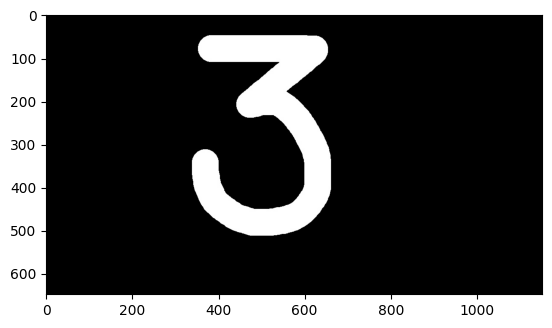

In [20]:
# Vamos a visualizar la imagen de un número que vas a crear en tu computador con la aplicación de paint, ésta imagen debe de tener un fondo negro y ser pintada en blanco, encontrarás un ejemplo en el repositorio
image = plt.imread("C:/Users/rusla/Desktop/el núm.jpg") # Coloca aquí la ruta de la imagen que hayas creado en formato jpg o png
plt.imshow(image)

In [21]:
# Con esta libreria transformaremos la imagen creada a un formato de 28x28 pixeles
from PIL import Image
pil = Image.open("C:/Users/rusla/Desktop/el núm.jpg").convert("L")
# recortar zona central aproximada
pil = pil.crop((300, 0, 800, 650))

image_resize = pil.resize((28, 28))

# Vamos transformar la nueva imagen en un array donde se almacenara la información de los pixeles
pixels = np.asarray(image_resize)

# eliminar ruido
pixels = (pixels > 80) * 255

In [22]:
# Necesitamos hacer algunas configuraciones a la imagen debido al formato de datos que esta alimentando al modelo y a la configuración de sklearn
image_final = pixels.reshape(1, -1)

image_final = pd.DataFrame(image_final, columns=X_train_mnist.columns)

El número es: [3]


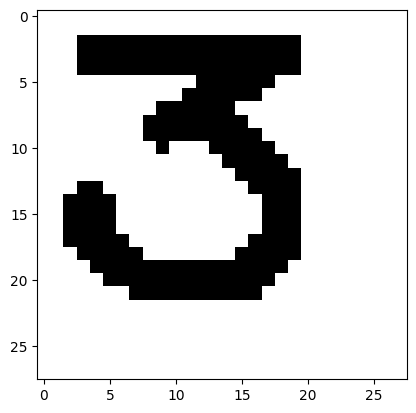

In [23]:
# Calcula la predicción del modelo con el número que creaste, ¿Fue la clasificación correcta? :O
print("El número es:", knn_mnist.predict(image_final))
plt.imshow(pixels, cmap=plt.cm.gray_r, interpolation='nearest')

## Overfit and Underfit
<p>¿Cual es mi numero ideal para elegir el parametro <i>k</i>? Vamos a calcular los valores de precisión para los conjuntos e entrenamiento y prueba para una rango de valores k. Al observar cómo difieren estos valores podremos observar cual es el mejor parametro sin caer en un <i>Overfit</i> o un <i>Underfit</i>.</p>

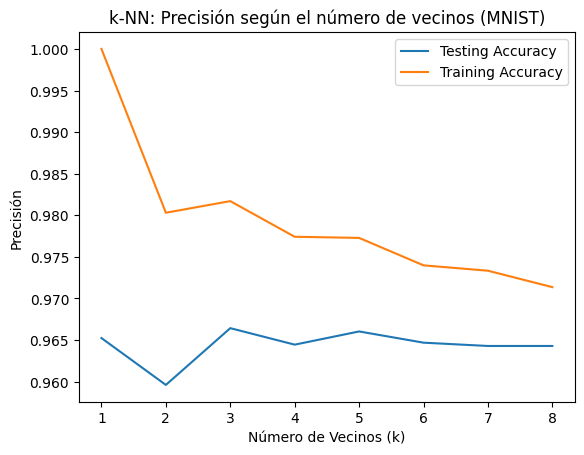

In [25]:
# Configuración de arreglos iniciales
# Para MNIST

y_mnist = df_mnist['label'].astype(int)
X_mnist = df_mnist.drop(columns=['label'])

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist, y_mnist, test_size=0.3, random_state=1)

neighbors = np.arange(1, 9)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Loop para diferentes valores de k
for i, k in enumerate(neighbors):
    
    # Clasificador k-NN para el parametro k
    knn = KNeighborsClassifier(n_neighbors=k)

    # Ajuste del clasificador al dataset de entrenamiento
    knn.fit(X_train_mnist, y_train_mnist)
    
    # Calculo de precisión sobre el dataset de entrenamiento
    train_accuracy[i] = knn.score(X_train_mnist, y_train_mnist)

    # Calculo de precisión sobre el dataset de prueba
    test_accuracy[i] = knn.score(X_test_mnist, y_test_mnist)

# Grafico para encontrar un valor óptimo de k
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training Accuracy')

plt.title('k-NN: Precisión según el número de vecinos (MNIST)')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Precisión')

plt.xticks(neighbors)
plt.legend()
plt.show()

In [26]:
# Mejor k
best_k = neighbors[np.argmax(test_accuracy)]
print(f"Mejor k: {best_k} con precisión en test: {max(test_accuracy):.4f}")

Mejor k: 3 con precisión en test: 0.9664


## Regresión Logística
<p>Haz la predicción de tu imagen, pero esta vez por medio de una Regresión Logística, ¿Cuál de los dos modelos te da mejores resultados?</p>

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_mnist)
X_test_scaled = scaler.transform(X_test_mnist)

# Modelo
model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    C=5
)
# Entrenamiento
clf = model.fit(X_train_scaled, y_train_mnist)

# Predicciones
y_pred_mnist = model.predict(X_test_scaled)

# Coeficientes
print("Intercepto (Beta0): ", clf.intercept_)
print("Pesos:", clf.coef_)
print("------------------------------------------------------------------")

# Precisión
score = model.score(X_test_scaled, y_test_mnist)
print("Score de precisión: ", score)

print("------------------------------------------------------------------")

# Reporte
print(classification_report(y_test_mnist, y_pred_mnist))

Intercepto (Beta0):  [-0.72409924 -1.14700283  0.72776979  0.75557176 -0.87091093  0.78016295
 -0.52381318 -0.60218535  1.49225153  0.11225551]
Pesos: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
------------------------------------------------------------------
Score de precisión:  0.9205555555555556
------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1247
           1       0.95      0.97      0.96      1395
           2       0.92      0.91      0.92      1257
           3       0.91      0.89      0.90      1321
           4       0.91      0.94      0.93      1232
           5       0.88      0.88      0.88      1111
           6       0.94      0.97      0.95      1258
           7       0.93      0.94      0.93      1285
           8       0.90      0.8

C:\Users\rusla\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [29]:
print("Suma coeficientes:", np.sum(np.abs(clf.coef_)))

Suma coeficientes: 487.5466214122199


In [30]:
print(clf.coef_[0][:20])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.00436263 0.00573457 0.00412048 0.00412048 0.         0.
 0.         0.        ]
